#### Testing Phase 1

In [58]:
import importlib
import os
import numpy as np
import strategy as strat_module

DAYS = 7
HOURS_PER_DAY = 24
PTS_PER_HOUR = 5
TOTAL_HOURS = DAYS * HOURS_PER_DAY

VERBOSE = True
VERBOSE_HOURS = 30

# choose any reasonable number for local testing
TEST_N_TEAMS = 5   # you + 4 fake competitors

def demand(price, beta):
    return 1.0 / (1.0 + np.exp(beta * price))

def clear_data():
    for f in ["test_historical_demands.csv", "test_historical_prices.csv"]:
        if os.path.exists(f):
            os.remove(f)

def append_data(price, outcome, n_teams=TEST_N_TEAMS):
    with open("test_historical_demands.csv", "a") as f:
        f.write(f"{price},{outcome}\n")

    comp_prices = np.random.uniform(10, 100, size=n_teams - 1)
    row = [price] + list(comp_prices)

    with open("test_historical_prices.csv", "a") as f:
        f.write(",".join(map(str, row)) + "\n")

def run_sim(beta=0.05):
    clear_data()
    importlib.reload(strat_module)

    for hour in range(TOTAL_HOURS):
        price = float(strat_module.strategy())
        price = float(np.clip(price, 1.0, 100.0))

        p_buy = demand(price, beta)
        outcomes = np.random.binomial(1, p_buy, size=PTS_PER_HOUR)

        for o in outcomes:
            append_data(price, int(o))

        if VERBOSE and hour < VERBOSE_HOURS:
            print(
                f"hour={hour+1:3d} | price={price:6.2f} "
                f"| buys={sum(outcomes)}/{PTS_PER_HOUR} | P(buy)={p_buy:.2f}"
            )

run_sim(beta=0.05)

hour=  1 | price= 50.00 | buys=0/5 | P(buy)=0.08
hour=  2 | price= 14.56 | buys=2/5 | P(buy)=0.33
hour=  3 | price= 27.13 | buys=1/5 | P(buy)=0.20
hour=  4 | price= 39.69 | buys=1/5 | P(buy)=0.12
hour=  5 | price= 52.26 | buys=0/5 | P(buy)=0.07
hour=  6 | price= 64.82 | buys=0/5 | P(buy)=0.04
hour=  7 | price= 77.38 | buys=1/5 | P(buy)=0.02
hour=  8 | price= 89.95 | buys=0/5 | P(buy)=0.01
hour=  9 | price=  2.00 | buys=4/5 | P(buy)=0.48
hour= 10 | price= 14.56 | buys=1/5 | P(buy)=0.33
hour= 11 | price= 94.68 | buys=0/5 | P(buy)=0.01
hour= 12 | price=100.00 | buys=0/5 | P(buy)=0.01
hour= 13 | price=  6.77 | buys=3/5 | P(buy)=0.42
hour= 14 | price= 27.13 | buys=2/5 | P(buy)=0.20
hour= 15 | price=  7.03 | buys=0/5 | P(buy)=0.41
hour= 16 | price= 25.97 | buys=1/5 | P(buy)=0.21
hour= 17 | price= 44.72 | buys=0/5 | P(buy)=0.10
hour= 18 | price= 53.31 | buys=1/5 | P(buy)=0.07
hour= 19 | price= 92.46 | buys=1/5 | P(buy)=0.01
hour= 20 | price= 37.18 | buys=1/5 | P(buy)=0.13
hour= 21 | price= 94

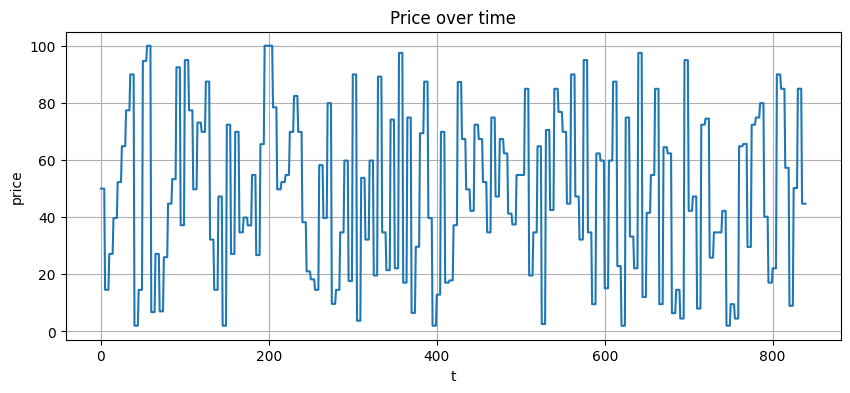

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("test_historical_demands.csv", header=None)
prices = df[0].values

plt.figure(figsize=(10,4))
plt.plot(prices)
plt.title("Price over time")
plt.xlabel("t")
plt.ylabel("price")
plt.grid()
plt.show()

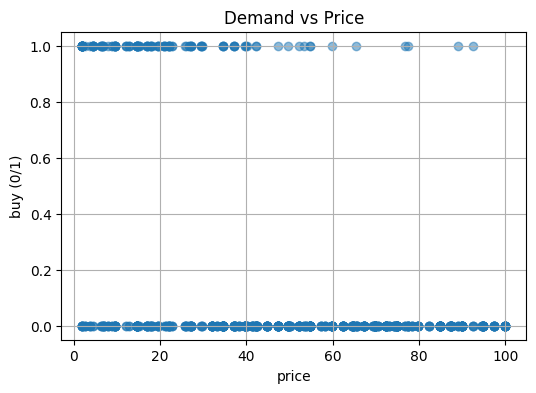

In [60]:
outcomes = df[1].values

plt.figure(figsize=(6,4))
plt.scatter(prices, outcomes, alpha=0.5)
plt.xlabel("price")
plt.ylabel("buy (0/1)")
plt.title("Demand vs Price")
plt.grid()
plt.show()

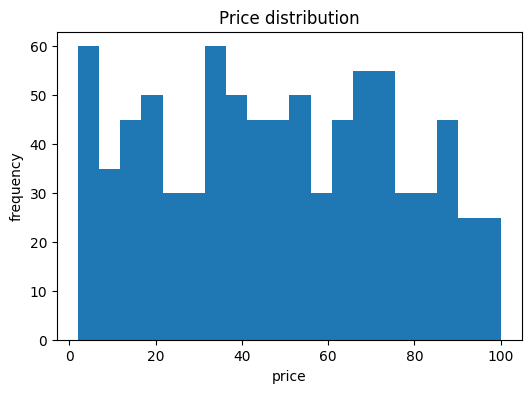

In [61]:
plt.figure(figsize=(6,4))
plt.hist(prices, bins=20)
plt.title("Price distribution")
plt.xlabel("price")
plt.ylabel("frequency")
plt.show()